15 March 8 PM

Simpli learn

We are going to implement SVM to classify between Cupcakes and Muffins

# Importing required libraries

In [ ]:
import numpy as np
import pandas as pd

from sklearn import svm

import matplotlib.pyplot as plt
import seaborn as sns; sns.set(font_scale=1.2) # setting the font scale

%matplotlib inline

In [ ]:
recipes = pd.read_csv("Cupcakes vs Muffins.csv")
print(recipes)

       Type  Flour  Milk  Sugar  Butter  Egg  Baking Powder  Vanilla  Salt
0    Muffin     55    28      3       7    5              2        0     0
1    Muffin     47    24     12       6    9              1        0     0
2    Muffin     47    23     18       6    4              1        0     0
3    Muffin     45    11     17      17    8              1        0     0
4    Muffin     50    25     12       6    5              2        1     0
5    Muffin     55    27      3       7    5              2        1     0
6    Muffin     54    27      7       5    5              2        0     0
7    Muffin     47    26     10      10    4              1        0     0
8    Muffin     50    17     17       8    6              1        0     0
9    Muffin     50    17     17      11    4              1        0     0
10  Cupcake     39     0     26      19   14              1        1     0
11  Cupcake     42    21     16      10    8              3        0     0
12  Cupcake     34    17 

# Visualizing Data

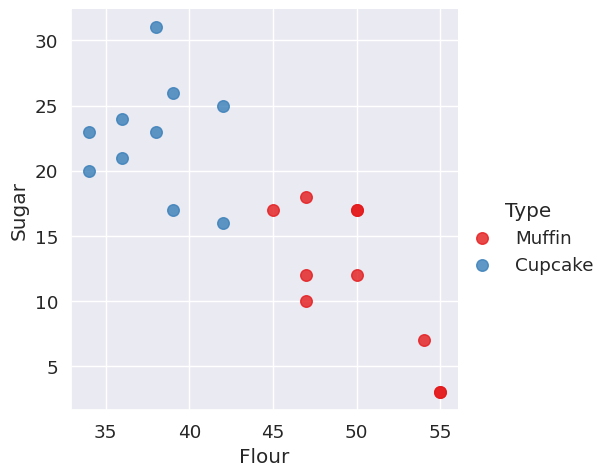

In [ ]:
# plot your data
sns.lmplot(x='Flour', y='Sugar', data=recipes, hue='Type', palette='Set1', fit_reg=False, scatter_kws={'s':70}) # somebody have experimented with sns and found this combination looks really good, so we are using this

# Pre-processing data

the model does not need to know whether it is cup cake or muffin, so we'll give it a number

In [ ]:
type_label = np.where(recipes['Type']=='Muffin',0,1) # In this if it is Muffin, then it gets the value 0 or else(cupcake), it gets the value 1
recipe_features = recipes.columns.values[1:].tolist() # we don't need the fist column so we first take columns from recipe and converting it to values (0,9) and we say [1:] which removes first and at last we convert it into list using tolist
# it gives the list of cols without 1st one 'Type'
print(recipe_features)

['Flour', 'Milk', 'Sugar', 'Butter', 'Egg', 'Baking Powder', 'Vanilla', 'Salt']


In [ ]:
ingredients = recipes[['Flour','Sugar']].values
print(ingredients)

[[55  3]
 [47 12]
 [47 18]
 [45 17]
 [50 12]
 [55  3]
 [54  7]
 [47 10]
 [50 17]
 [50 17]
 [39 26]
 [42 16]
 [34 20]
 [39 17]
 [38 23]
 [42 25]
 [36 21]
 [38 31]
 [36 24]
 [34 23]]


# Model fitting

In [ ]:
model = svm.SVC(kernel='linear') #support vector classifier and svr stands for suppor vector regression
model.fit(ingredients, type_label)

SVC(kernel='linear')

# Separating Hyperplane

In [ ]:
# get the separating hyperplane
w = model.coef_[0]
a = -w[0] / w[1] # slope
xx = np.linspace(30,60)
yy = a*xx - (model.intercept_[0]) / w[1]

# plot the parallels in the separating hyperplane that pass through the support vectors
b = model.support_vectors_[0]
yy_down = a*xx + (b[1] - a*b[0])
b = model.support_vectors_[-1]
yy_up = a*xx + (b[1] - a*b[0])

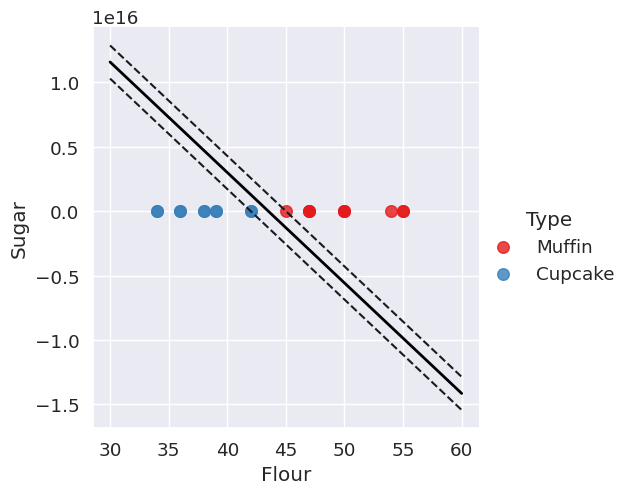

In [ ]:
sns.lmplot(x='Flour', y='Sugar', data=recipes, hue='Type', palette='Set1', fit_reg=False, scatter_kws={'s':70})
plt.plot(xx, yy, linewidth=2, color='black') # hyperplane
plt.plot(xx, yy_down, 'k--') # down margin
plt.plot(xx,yy_up,'k--') # up margin

In [ ]:
# create a functin to predict muffin or cupcake
def muffin_or_cupcake(flour, sugar):
  if(model.predict([[flour, sugar]]))==0:
    print("you're looking at a muffin recipe!")
  else:
    print("you're looking at a cupcake recipe!")

In [ ]:
#predict if 50part of flour and 20part of sugar
muffin_or_cupcake(50,20)

you're looking at a muffin recipe!


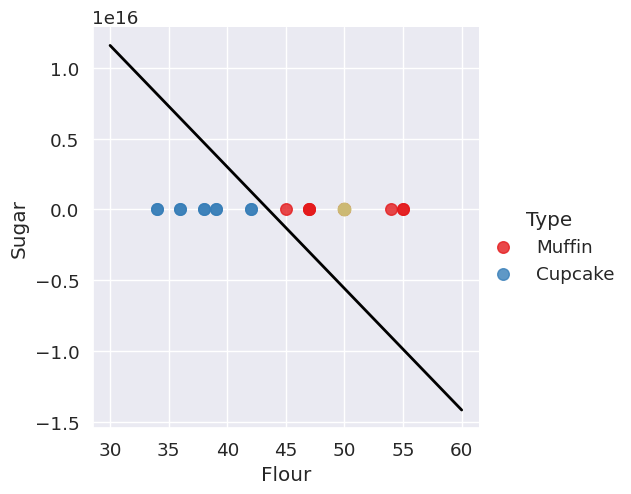

In [ ]:
# let's plot this on the graph
sns.lmplot(x='Flour', y='Sugar', data=recipes, hue='Type', palette='Set1', fit_reg=False, scatter_kws={'s':70})
plt.plot(xx, yy, linewidth=2, color='black')
plt.plot(50, 20, 'yo', markersize='9')